## 15 June 2026
## Sapkas Michail
### Lunar Lander - Final Project for Deep Neural Networks

Implement the 

# Deep Q-Learning Network (DQN) algorithm

- with decaying Epsilon greedy exploration and 
- with Boltzmann exploration

In [3]:
import torch
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time
import os

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # For Mac Apple Silicon users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


Defining all the hyperparameters of the algorithm: 

- **LATENT_DIM** is the dimension of the hidden layer of the neural network
- **BATCH_SIZE** is the number of samples randomly sampled from the replay buffer to train the network
- **LEARNING_RATE** is self explanatory. I am using adam
- **GAMMA** is the discount factor for future rewards (in this context, because it is multiplying the estimated future rewards Q it can also represent the "trust" or "importance" of our estimation)
- **MIN_REPLAY_SIZE** is the warm-up samples (random actions) that fill the replay buffer before training starts
- **REPLAY_BUFFER_SIZE** is the capacity of the replay buffer
- **TRAIN_FREQ** is the frequency of training the network in steps
- **TARGET_UPDATE_FREQ** is the frequency of updating the target network in steps
- **TAU** is the soft update parameter using the polyak method for updating the target network
- **EPSILON_START** is the initial value of epsilon for the epsilon-greedy exploration strategy
- **EPSILON_DECAY** is the multiplicative factor by which epsilon is decayed after each episode
- **EPSILON_MIN** is the minimum value of epsilon for the epsilon-greedy exploration strategy
- **TOTAL_TIMESTEPS** is self explanatory. The total number of steps until the training is finished

In [4]:
LATENT_DIM = 128
BATCH_SIZE = 256

LEARNING_RATE = 1e-3

GAMMA = 0.99

MIN_REPLAY_SIZE = 10_000
REPLAY_BUFFER_SIZE = 100_000

TRAIN_FREQ = 4
TARGET_UPDATE_FREQ = 100
TAU = 0.5

EPSILON_START = 1.0
EPSILON_DECAY = 0.9945
EPSILON_MIN = 0.02

TOTAL_TIMESTEPS = 300_000

The Neural Network takes as input the state of the environment (vector of 8 floats) and outputs the Q-values for each action (vector of 4 floats).

In [ ]:
class QNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(8, LATENT_DIM),
            nn.ReLU(),
            nn.Linear(LATENT_DIM, LATENT_DIM),
            nn.ReLU(),
            nn.Linear(LATENT_DIM, 4),
        )

    def forward(self, x):
        return self.network(x)

Just defining the polyak update method for the target network just like shown here (p2s05-deepRL-part1):

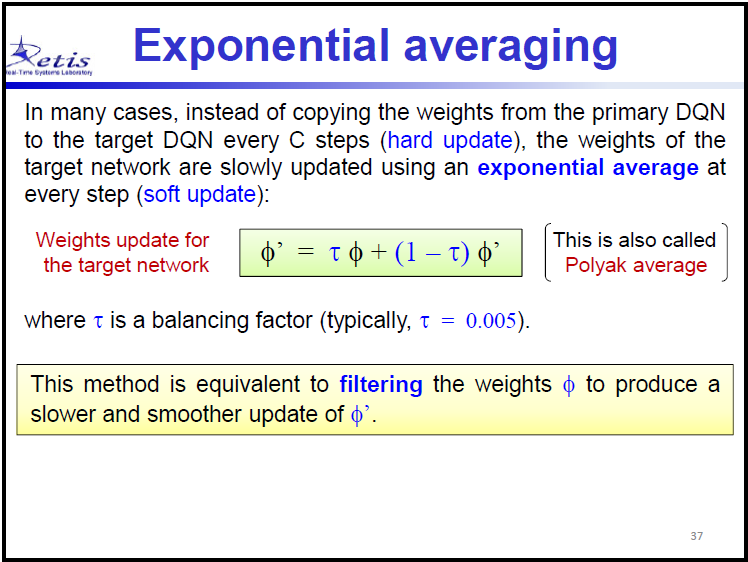

In [ ]:
def polyak_update(policy_net, target_net):
    for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
        target_param.data.copy_(TAU * policy_param.data + (1.0 - TAU) * target_param.data)

Ok, time to define the training step:
- Randomly sample BATCH_SIZE number of transition tuples (s, a, r, s', done) from the replay buffer
- Logistics: unpack and convert to tensors, move to device (GPU or CPU)
- Do a forward pass on the Qnetwork to get the Q-values for the four possible actions. These represent the estimation of the future rewards ofr each action that the agent can take in the current state s.
- Use the following formula to calculate the target Q-values for the actions taken in the sampled transitions:

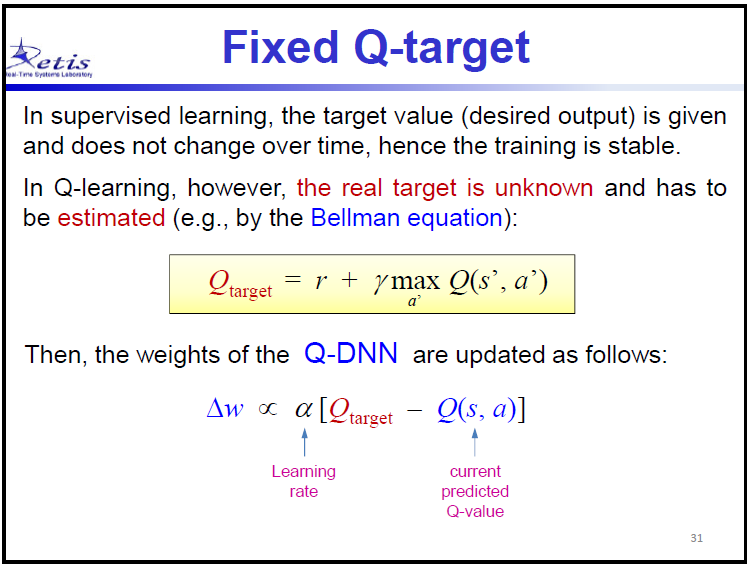

- Use this loss function for training the Qnetwork:

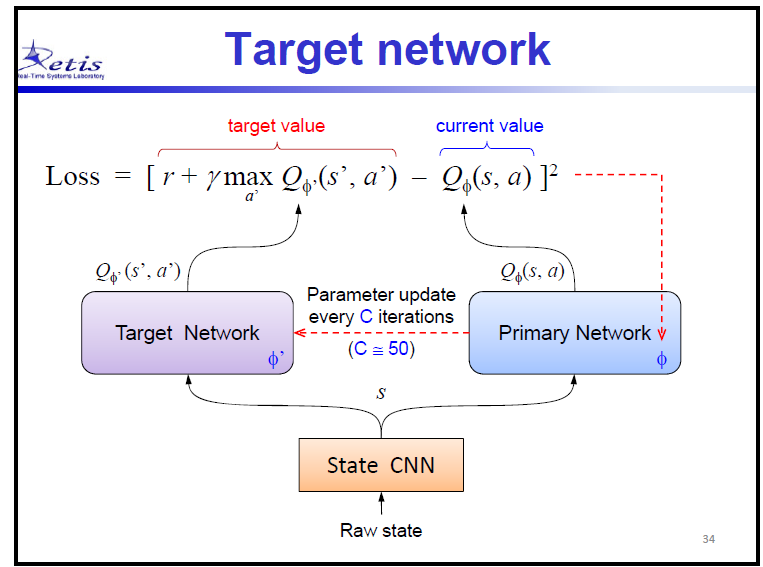

In [ ]:
# TRAINING STEP
def train_step(policy_net, target_net):
    mini_batch = random.sample(replay_buffer, BATCH_SIZE)

    # Unpack transitions efficiently
    states, actions, rewards, next_states, dones = zip(*mini_batch)

    states = torch.FloatTensor(np.array(states)).to(device)
    actions = torch.FloatTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # Get Q-values from Policy Net
    current_q_values = policy_net(states).gather(1, actions)

    # Get target Q-values from Target Net (Stability Improvement)
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1)[0].unsqueeze(1)
        target_q_values = rewards + (GAMMA * next_q_values * (1 - dones))

    loss = loss_fn(current_q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Define a simple function to decay epsilon after each episode:|

In [17]:
def update_epsilon_decay(epsilon):
    return max(EPSILON_MIN, epsilon * EPSILON_DECAY)

Finally after initializing the replay buffer, epsilon and all the empty lists and counters we need to keep track of the training process, we can start the training loop. The training loop is as follows:

- The gym.make and env.reset function are given by the environment and are standard
- The we will do TOTAL_TIMESTEPS number of steps in the environment. For each step we will do the following:
  - Select an action using the epsilon-greedy exploration strategy
  - Take a step in the environment using env.step(action) and get the next state, reward, done flag and info
  - Store the transition tuple (state, action, reward, next_state, done) in the replay buffer
  - If the replay buffer has enough samples (MIN_REPLAY_SIZE), we will train the Qnetwork every TRAIN_FREQ steps
  - If the current step is a multiple of TARGET_UPDATE_FREQ, we will update the target network using the polyak update method
  - If done is True, we will reset the environment and decay epsilon

In [ ]:
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)
epsilon = EPSILON_START

policy_net = QNetwork().to(device)
target_net = QNetwork().to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Target net never calculates gradients

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()

# STATISTICS & ADAPTIVE TRACKING
episode_rewards = []
episode_lengths = []
moving_avg_rewards = []
current_episode_reward = 0
current_episode_length = 0
prev_avg_reward = None

# ENVIRONMENT LOOP 
env = gym.make("LunarLander-v3", continuous=False)
observation, info = env.reset(seed=42)

print("Training started...", flush=True)
pbar = tqdm(range(TOTAL_TIMESTEPS), desc="Training")

for step in pbar:
    # Action Selection
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)
        with torch.no_grad():
            action = torch.argmax(policy_net(state_tensor)).item()

    # Step environment
    next_observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    current_episode_reward += reward
    current_episode_length += 1

    # Save to buffer
    replay_buffer.append((observation, action, reward, next_observation, done))
    observation = next_observation

    # Only train once every TRAIN_FREQ steps to preserve clock speed
    if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
        train_step(policy_net, target_net)

    # Periodically copy weights to the Target Network
    if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TARGET_UPDATE_FREQ == 0:
        polyak_update(policy_net,target_net)

    # Handle Episode Termination
    if done:
        episode_rewards.append(current_episode_reward)
        episode_lengths.append(current_episode_length)

        avg_reward = np.mean(episode_rewards[-100:])
        moving_avg_rewards.append(avg_reward)

        epsilon = update_epsilon_decay(epsilon)

        pbar.set_postfix({
            "Ep": len(episode_rewards),
            "Steps": f"{current_episode_length}",
            "Last Reward": f"{current_episode_reward:.1f}",
            "100-Ep Avg": f"{avg_reward:.1f}",
            "Epsilon": f"{epsilon:.3f}"
        })

        observation, info = env.reset()
        current_episode_reward = 0
        current_episode_length = 0

env.close()
print("Training Complete!")

Training started...


Training: 100%|██████████| 300000/300000 [14:12<00:00, 352.06it/s, Ep=783, Steps=323, Last Reward=229.6, 100-Ep Avg=220.6, Epsilon=0.024]  

Training Complete!


Save the trained model weights so we can showcase a live demo later

In [ ]:
# Save the trained model weights
torch.save(policy_net.state_dict(), "dqn_lunar_lander.pth")
print("Model saved to dqn_lunar_lander.pth")

Model saved to dqn_lunar_lander.pth


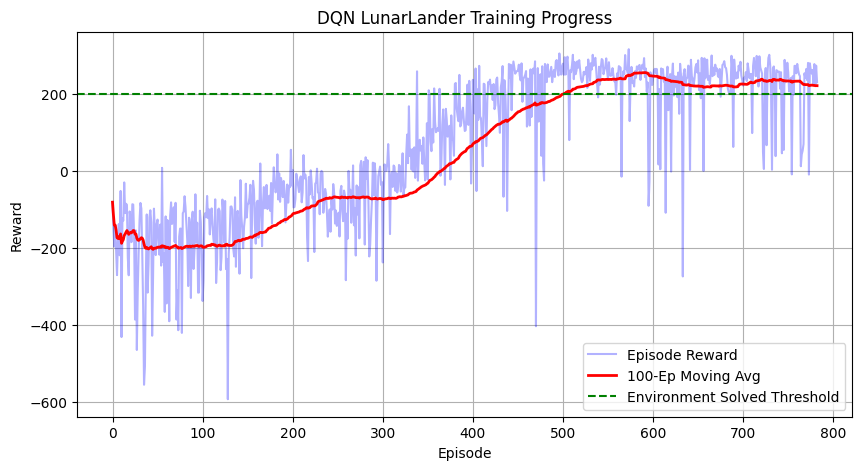

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color="blue", label="Episode Reward")
plt.plot(moving_avg_rewards, color="red", linewidth=2, label="100-Ep Moving Avg")
plt.axhline(y=200, color="green", linestyle="--", label="Environment Solved Threshold")
plt.title("DQN LunarLander Training Progress")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.savefig("dqn_lunar_lander_training_progress.png")
plt.show()

In [28]:
NUM_EPISODES = 2

test_policy_net = QNetwork().to(device)
test_policy_net.load_state_dict(torch.load("dqn_lunar_lander_0.pth", map_location=device))
test_policy_net.eval()

env = gym.make("LunarLander-v3", continuous=False, render_mode="human")

for episode in range(NUM_EPISODES):
    observation, info = env.reset()
    episode_reward = 0
    done = False

    print(f"Starting Evaluation Episode {episode + 1}...")

    while not done:
        # Convert observation to tensor and map it to the active device
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)

        # Always Exploit: Pick the best action according to the network
        with torch.no_grad():
            action = torch.argmax(test_policy_net(state_tensor)).item()

        # Step the environment
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_reward += reward

    print(f"Episode {episode + 1} Finished! Total Reward: {episode_reward:.1f}\n")

env.close()
print("Evaluation Complete!")

Starting Evaluation Episode 1...
Episode 1 Finished! Total Reward: 183.8

Starting Evaluation Episode 2...
Episode 2 Finished! Total Reward: 131.2

Evaluation Complete!


# Code for stability analysis
### 10 Runs of DQN with different random seeds using the epsilon greedy exploration method

In [ ]:
N_RUNS = 10

# Directory to save checkpoint data
SAVE_DIR = "./DQN_stability_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

all_runs_logs = []          # Will hold the logged rewards for each run
all_runs_lengths_logs = []  # Will hold the logged final episode count for each run

print(f"Starting Stability Analysis for {N_RUNS} runs...", flush=True)

for run in range(N_RUNS):
    print(f"\n--- Starting Run {run + 1}/{N_RUNS} ---")
    
    # File paths for saving this specific run's data
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy") # Added this definition
    
    # --- INTERRUPTION PROTECTION: CHECK FOR EXISTING DATA ---
    if os.path.exists(reward_file) and os.path.exists(length_file):
        print(f"-> Found existing data for Run {run + 1}. Loading and skipping...")
        run_history = np.load(reward_file).tolist()
        run_lengths_history = np.load(length_file).item() # Loaded as a single value item
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        continue  # Skip to the next run
    
    # 1. RESET / RE-INITIALIZE AGENT & ENVIRONMENT FOR EACH RUN
    env = gym.make("LunarLander-v3", continuous=False)
    
    # Generate a new seed per run for true variance analysis
    run_seed = 42 + run 
    observation, info = env.reset(seed=run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    
    # Re-initialize networks/buffers here:
    policy_net = QNetwork().to(device)
    target_net = QNetwork().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval() # Target net never calculates gradients

    replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)
    epsilon = EPSILON_START
    
    # STATISTICS & ADAPTIVE TRACKING
    episode_rewards = []
    current_episode_reward = 0
    current_episode_length = 0
    
    optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    
    run_history = []           
    
    pbar = tqdm(range(TOTAL_TIMESTEPS), desc=f"Run {run + 1} Progress")

    for step in pbar:
        # Action Selection
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)
            with torch.no_grad():
                action = torch.argmax(policy_net(state_tensor)).item()

        # Step environment
        next_observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        current_episode_reward += reward
        current_episode_length += 1

        # Save to buffer
        replay_buffer.append((observation, action, reward, next_observation, done))
        observation = next_observation

        # Only train once every TRAIN_FREQ steps
        if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
            train_step(policy_net, target_net)

        # Periodically copy weights to the Target Network
        if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TARGET_UPDATE_FREQ == 0:
            polyak_update(policy_net, target_net)

        # Note: If no episodes finished yet, default to 0 to prevent empty slice mean issues
        avg_reward = np.mean(episode_rewards[-100:]) if episode_rewards else 0.0
        run_history.append(avg_reward)

        # Handle Episode Termination
        if done:
            episode_rewards.append(current_episode_reward)
            epsilon = update_epsilon_decay(epsilon)

            pbar.set_postfix({
                "Ep": len(episode_rewards),
                "Steps": f"{current_episode_length}",
                "Last Reward": f"{current_episode_reward:.1f}",
                "100-Ep Avg": f"{np.mean(episode_rewards[-100:]):.1f}",
                "Epsilon": f"{epsilon:.3f}"
            })

            observation, info = env.reset()
            current_episode_reward = 0
            current_episode_length = 0
            
    # The final total count of completed episodes for this entire run
    final_episode_count = len(episode_rewards)
    env.close()
    
    # --- SAVE TO NUMPY ARRAYS AFTER EACH RUN ---
    np.save(reward_file, np.array(run_history))
    np.save(length_file, np.array(final_episode_count)) # Saves just the single scalar integer
    print(f"-> Saved data for Run {run + 1} to {SAVE_DIR}")
    
    all_runs_logs.append(run_history)
    all_runs_lengths_logs.append(final_episode_count)

print("\nAll training runs finished or loaded! Generating stability plot...")

Starting Stability Analysis for 10 runs...

--- Starting Run 1/10 ---


Run 1 Progress: 100%|█| 300000/300000 [05:09<00:00, 969.04it/s, Ep=859, Steps=17


-> Saved data for Run 1 to ./DQN_stability_analysis

--- Starting Run 2/10 ---


Run 2 Progress: 100%|█| 300000/300000 [05:11<00:00, 963.45it/s, Ep=839, Steps=14


-> Saved data for Run 2 to ./DQN_stability_analysis

--- Starting Run 3/10 ---


...

-> Saved data for Run 8 to ./DQN_stability_analysis

--- Starting Run 9/10 ---


Run 9 Progress: 100%|█| 300000/300000 [05:20<00:00, 936.49it/s, Ep=822, Steps=22


-> Saved data for Run 9 to ./DQN_stability_analysis

--- Starting Run 10/10 ---


Run 10 Progress: 100%|█| 300000/300000 [05:05<00:00, 982.28it/s, Ep=790, Steps=1

-> Saved data for Run 10 to ./DQN_stability_analysis

All training runs finished or loaded! Generating stability plot...


Loading Stability Analysis data for 10 runs from './DQN_stability_analysis'...
-> Successfully loaded Run 1 (Total Episodes: 859)
-> Successfully loaded Run 2 (Total Episodes: 839)
-> Successfully loaded Run 3 (Total Episodes: 849)
-> Successfully loaded Run 4 (Total Episodes: 732)
-> Successfully loaded Run 5 (Total Episodes: 771)
-> Successfully loaded Run 6 (Total Episodes: 833)
-> Successfully loaded Run 7 (Total Episodes: 880)
-> Successfully loaded Run 8 (Total Episodes: 689)
-> Successfully loaded Run 9 (Total Episodes: 822)
-> Successfully loaded Run 10 (Total Episodes: 790)

All data loaded successfully! Processing metrics and generating stability plot...


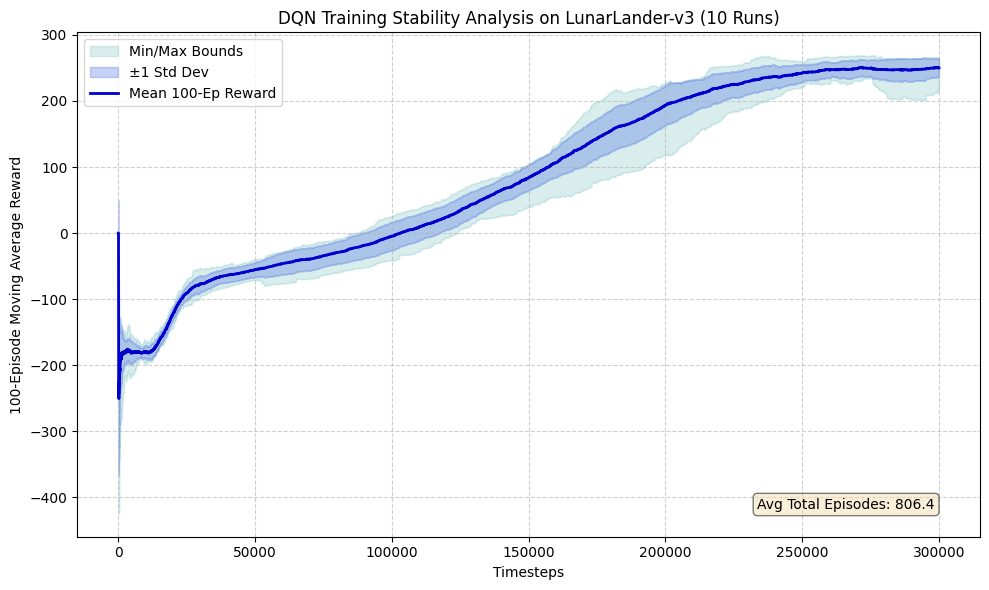

In [ ]:
# Configuration
N_RUNS = 10
SAVE_DIR = "./DQN_stability_analysis"

all_runs_logs = []
all_runs_lengths_logs = []

print(f"Loading Stability Analysis data for {N_RUNS} runs from '{SAVE_DIR}'...")

# --- LOAD DATA FROM SAVED ARRAYS ---
for run in range(N_RUNS):
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    if os.path.exists(reward_file) and os.path.exists(length_file):
        # Load the step-by-step reward history
        run_history = np.load(reward_file).tolist()
        # Load the scalar episode count (.item() extracts the scalar from the 0D array)
        run_lengths_history = np.load(length_file).item()
        
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        print(f"-> Successfully loaded Run {run + 1} (Total Episodes: {run_lengths_history})")
    else:
        raise FileNotFoundError(f"Missing data files for Run {run + 1}. Please ensure both {reward_file} and {length_file} exist.")

print("\nAll data loaded successfully! Processing metrics and generating stability plot...")

# --- PROCESS METRICS ---
# Convert to a 2D numpy array: shape (N_RUNS, timesteps_logged)
data_matrix = np.array(all_runs_logs)

# Calculate stats across the runs (axis=0)
mean_trend = np.mean(data_matrix, axis=0)
std_trend = np.std(data_matrix, axis=0)
min_trend = np.min(data_matrix, axis=0)
max_trend = np.max(data_matrix, axis=0)

# Since your training loop saved data at EVERY timestep, your effective LOG_FREQ is 1
effective_log_freq = 1
x_axis = np.arange(len(mean_trend)) * effective_log_freq

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# 1. Fill the Min/Max total range (Light Cyan shadow)
plt.fill_between(
    x_axis, 
    min_trend, 
    max_trend, 
    color="darkcyan", 
    alpha=0.15, 
    label="Min/Max Bounds"
)

# 2. Fill the Standard Deviation shadow (Royal Blue shadow)
plt.fill_between(
    x_axis, 
    mean_trend - std_trend, 
    mean_trend + std_trend, 
    color="royalblue", 
    alpha=0.3, 
    label="±1 Std Dev"
)

# 3. Plot the mean line (Deep Blue line)
plt.plot(x_axis, mean_trend, label="Mean 100-Ep Reward", color="mediumblue", lw=2)

# Graph embellishments
plt.title(f"DQN Training Stability Analysis on LunarLander-v3 ({N_RUNS} Runs)")
plt.xlabel("Timesteps")
plt.ylabel("100-Episode Moving Average Reward")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

# Display total average episodes completed across all runs as text on the plot
avg_final_episodes = np.mean(all_runs_lengths_logs)
plt.text(0.95, 0.05, f"Avg Total Episodes: {avg_final_episodes:.1f}", 
         transform=plt.gca().transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

# Boltzmann exploration method

#### Note: Run the cells above first to define the hyperparameters and the DQN class before running the cells below

Moving on to implementing the Boltzmann exploration method we will need to define 3 hyperparameters for decaying the temperature parameter T. I will use temperature instead of β so that I can decay it over time instead of increasing it:

In [11]:
# Boltzmann Exploration Parameters
T_START = 3.0
T_DECAY = 0.985
T_MIN = 0.01

I will implement the Boltzmann method from ps1s04-RL-part1 using the stability trick:

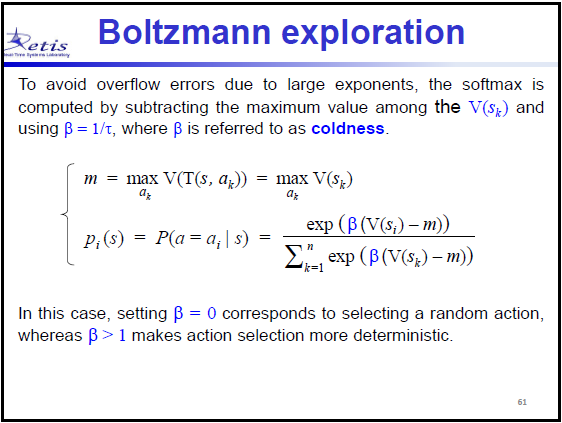

In [ ]:
def update_temperature(current_T):
    return max(T_MIN, current_T * T_DECAY)

def select_action(boltz_policy_net, state, current_T):
    """Selects an action using Boltzmann (Softmax) Exploration."""
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    
    with torch.no_grad():
        q_values = boltz_policy_net(state_tensor)
        
        # Numerical stability tweak: Subtract max Q-value before dividing by temperature
        # This prevents exponential overflow errors without changing the probabilities.
        q_values = q_values - torch.max(q_values)
        
        scaled_q = q_values / current_T
        probabilities = torch.softmax(scaled_q, dim=1)
        
        # Sample an action index from the probability distribution
        action_distribution = torch.distributions.Categorical(probabilities)
        return action_distribution.sample().item()

In [13]:
# You have to run the cell that defines the class QNetwork before running this cell, otherwise it will throw an error.
boltz_policy_net = QNetwork().to(device)
boltz_target_net = QNetwork().to(device)
boltz_target_net.load_state_dict(boltz_policy_net.state_dict())
boltz_target_net.eval() # Target net never calculates gradients

optimizer = optim.Adam(boltz_policy_net.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()

In [ ]:
# Using the same training step as the epsilon greedy, so make sure you have run the cell that defines the train_step function
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)

# Exploration and Statistics Tracker Tracking
Tee = T_START
episode_rewards = []
episode_lengths = []
moving_avg_rewards = []

current_episode_reward = 0
current_episode_length = 0

# ENVIRONMENT LOOP
env = gym.make("LunarLander-v3", continuous=False)
observation, info = env.reset(seed=42)

print(f"Training started using {device}...", flush=True)
pbar = tqdm(range(TOTAL_TIMESTEPS), desc="Training")

for step in pbar:
    # 1. Action selection via Boltzmann Exploration
    action = select_action(boltz_policy_net, observation, Tee)

    # Step
    next_observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    current_episode_reward += reward
    current_episode_length += 1

    # Store to memory
    replay_buffer.append((observation, action, reward, next_observation, done))
    observation = next_observation

    # Only train once every TRAIN_FREQ steps to preserve clock speed
    if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
        train_step(boltz_policy_net, boltz_target_net)

    # Copy Policy Net parameters to Target Net
    if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TARGET_UPDATE_FREQ == 0:
        polyak_update(boltz_policy_net, boltz_target_net)

    # Check if Episode ends
    if done:
        episode_rewards.append(current_episode_reward)
        episode_lengths.append(current_episode_length)
        
        avg_reward = np.mean(episode_rewards[-100:])
        moving_avg_rewards.append(avg_reward)

        # Decay temperature exploration rate
        Tee = update_temperature(Tee)

        pbar.set_postfix({
            "Ep": len(episode_rewards),
            "Steps": f"{current_episode_length}",
            "Last Reward": f"{current_episode_reward:.1f}",
            "100-Ep Avg": f"{avg_reward:.1f}",
            "T": f"{Tee:.3f}"
        })

        # Reset episode flags
        observation, info = env.reset()
        current_episode_reward = 0
        current_episode_length = 0

pbar.close()
env.close()
print("Training Complete!")

Training started using cuda...


Training:   0%|          | 0/300000 [00:00<?, ?it/s]

Training: 100%|██████████| 300000/300000 [11:22<00:00, 439.45it/s, Ep=886, Steps=204, Last Reward=245.7, 100-Ep Avg=263.7, T=0.010] 

Training Complete!


In [42]:
# Save the trained model weights
torch.save(boltz_policy_net.state_dict(), "dqn_botlz_lunar_lander.pth")
print("Model saved to dqn_botlz_lunar_lander.pth")

Model saved to dqn_botlz_lunar_lander.pth


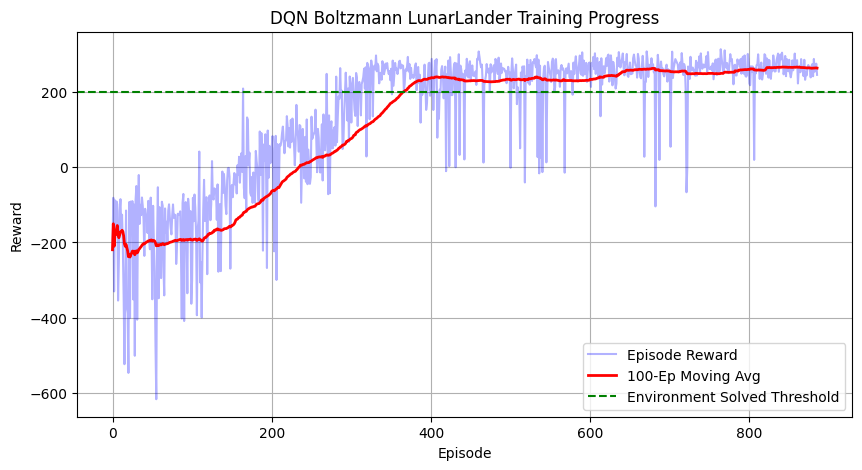

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color="blue", label="Episode Reward")
plt.plot(moving_avg_rewards, color="red", linewidth=2, label="100-Ep Moving Avg")
plt.axhline(y=200, color="green", linestyle="--", label="Environment Solved Threshold")
plt.title("DQN Boltzmann LunarLander Training Progress")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.savefig("dqn_botlz_lunar_lander.png")
plt.show()

In [44]:
NUM_EPISODES = 2

test_policy_net = QNetwork().to(device)
test_policy_net.load_state_dict(torch.load("dqn_botlz_lunar_lander.pth", map_location=device))
test_policy_net.eval()  # Set network to evaluation mode (turns off dropout, batchnorm etc.)

env = gym.make("LunarLander-v3", continuous=False, render_mode="human")

for episode in range(NUM_EPISODES):
    observation, info = env.reset()
    episode_reward = 0
    done = False

    print(f"Starting Evaluation Episode {episode + 1}...")

    while not done:
        # Convert observation to tensor and map it to the active device
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)

        # Always Exploit: Pick the best action according to the network
        with torch.no_grad():
            action = torch.argmax(test_policy_net(state_tensor)).item()

        # Step the environment
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_reward += reward

    print(f"Episode {episode + 1} Finished! Total Reward: {episode_reward:.1f}\n")

env.close()
print("Evaluation Complete!")

Starting Evaluation Episode 1...
Episode 1 Finished! Total Reward: 302.9

Starting Evaluation Episode 2...
Episode 2 Finished! Total Reward: 229.9

Evaluation Complete!


# Code for stability analysis
### 10 Runs of DQN with different random seeds using the Boltzmann exploration method

In [16]:
import os
N_RUNS = 10

# Directory to save Boltzmann checkpoint data
SAVE_DIR = "./DQN_Boltzmann_stability_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

all_runs_logs = []          # Will hold the logged moving average rewards for each run
all_runs_lengths_logs = []  # Will hold the logged final episode count for each run

print(f"Starting Stability Analysis for {N_RUNS} runs using Boltzmann Exploration...", flush=True)

for run in range(N_RUNS):
    print(f"\n--- Starting Run {run + 1}/{N_RUNS} ---")
    
    # File paths for saving this specific run's data
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    # --- INTERRUPTION PROTECTION: CHECK FOR EXISTING DATA ---
    if os.path.exists(reward_file) and os.path.exists(length_file):
        print(f"-> Found existing data for Run {run + 1}. Loading and skipping...")
        run_history = np.load(reward_file).tolist()
        run_lengths_history = np.load(length_file).item() # Loaded as a single value item
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        continue  # Skip to the next run
    
    # 1. RESET / RE-INITIALIZE AGENT & ENVIRONMENT FOR EACH RUN
    env = gym.make("LunarLander-v3", continuous=False)
    
    # Generate a new seed per run for true variance analysis
    run_seed = 42 + run 
    observation, info = env.reset(seed=run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    
    # Re-initialize Boltzmann networks/buffers here
    boltz_policy_net = QNetwork().to(device)
    boltz_target_net = QNetwork().to(device)
    boltz_target_net.load_state_dict(boltz_policy_net.state_dict())
    boltz_target_net.eval() 

    replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)
    Tee = T_START
    
    # STATISTICS & ADAPTIVE TRACKING
    episode_rewards = []
    current_episode_reward = 0
    current_episode_length = 0
    
    optimizer = optim.Adam(boltz_policy_net.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    
    # run_history tracks the step-by-step moving average over TOTAL_TIMESTEPS
    run_history = []           
    
    pbar = tqdm(range(TOTAL_TIMESTEPS), desc=f"Run {run + 1} Progress")

    for step in pbar:
        # 1. Action selection via Boltzmann Exploration
        action = select_action(boltz_policy_net, observation, Tee)

        # Step environment
        next_observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        current_episode_reward += reward
        current_episode_length += 1

        # Save to buffer
        replay_buffer.append((observation, action, reward, next_observation, done))
        observation = next_observation

        # Only train once every TRAIN_FREQ steps
        if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
            train_step(boltz_policy_net, boltz_target_net)

        # Periodically copy weights to the Target Network
        if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TARGET_UPDATE_FREQ == 0:
            polyak_update(boltz_policy_net, boltz_target_net)

        # Step-by-step tracking matching your epsilon-greedy setup
        avg_reward = np.mean(episode_rewards[-100:]) if episode_rewards else 0.0
        run_history.append(avg_reward)

        # Handle Episode Termination
        if done:
            episode_rewards.append(current_episode_reward)
            
            # Recalculate avg_reward for the postfix print
            avg_reward = np.mean(episode_rewards[-100:])
            
            # Decay temperature exploration rate
            Tee = update_temperature(Tee)

            pbar.set_postfix({
                "Ep": len(episode_rewards),
                "Steps": f"{current_episode_length}",
                "Last Reward": f"{current_episode_reward:.1f}",
                "100-Ep Avg": f"{avg_reward:.1f}",
                "T": f"{Tee:.3f}"
            })

            # Reset episode flags
            observation, info = env.reset()
            current_episode_reward = 0
            current_episode_length = 0
            
    # The final total count of completed episodes for this entire run
    final_episode_count = len(episode_rewards)
    env.close()
    
    # --- SAVE TO NUMPY ARRAYS AFTER EACH RUN ---
    np.save(reward_file, np.array(run_history))
    np.save(length_file, np.array(final_episode_count)) # Saves just the single scalar integer
    print(f"-> Saved data for Run {run + 1} to {SAVE_DIR}")
    
    all_runs_logs.append(run_history)
    all_runs_lengths_logs.append(final_episode_count)

print("\nAll Boltzmann training runs finished or loaded! Generating stability plot...")

Starting Stability Analysis for 10 runs using Boltzmann Exploration...

--- Starting Run 1/10 ---
-> Found existing data for Run 1. Loading and skipping...

--- Starting Run 2/10 ---
-> Found existing data for Run 2. Loading and skipping...

--- Starting Run 3/10 ---
-> Found existing data for Run 3. Loading and skipping...

--- Starting Run 4/10 ---
-> Found existing data for Run 4. Loading and skipping...

--- Starting Run 5/10 ---
-> Found existing data for Run 5. Loading and skipping...

--- Starting Run 6/10 ---


Run 6 Progress: 100%|█| 300000/300000 [07:12<00:00, 693.20it/s, Ep=767, Steps=26


-> Saved data for Run 6 to ./DQN_Boltzmann_stability_analysis

--- Starting Run 7/10 ---


Run 7 Progress: 100%|█| 300000/300000 [06:36<00:00, 756.18it/s, Ep=783, Steps=39


-> Saved data for Run 7 to ./DQN_Boltzmann_stability_analysis

--- Starting Run 8/10 ---


...

-> Saved data for Run 8 to ./DQN_Boltzmann_stability_analysis

--- Starting Run 9/10 ---


Run 9 Progress: 100%|█| 300000/300000 [08:53<00:00, 562.72it/s, Ep=826, Steps=27


-> Saved data for Run 9 to ./DQN_Boltzmann_stability_analysis

--- Starting Run 10/10 ---


Run 10 Progress: 100%|█| 300000/300000 [06:58<00:00, 716.18it/s, Ep=864, Steps=2

-> Saved data for Run 10 to ./DQN_Boltzmann_stability_analysis

All Boltzmann training runs finished or loaded! Generating stability plot...


Loading Stability Analysis data for 10 runs from './DQN_Boltzmann_stability_analysis'...
-> Successfully loaded Run 1 (Total Episodes: 848)
-> Successfully loaded Run 2 (Total Episodes: 741)
-> Successfully loaded Run 3 (Total Episodes: 650)
-> Successfully loaded Run 4 (Total Episodes: 875)
-> Successfully loaded Run 5 (Total Episodes: 862)
-> Successfully loaded Run 6 (Total Episodes: 767)
-> Successfully loaded Run 7 (Total Episodes: 783)
-> Successfully loaded Run 8 (Total Episodes: 837)
-> Successfully loaded Run 9 (Total Episodes: 826)
-> Successfully loaded Run 10 (Total Episodes: 864)

All data loaded successfully! Processing metrics and generating stability plot...


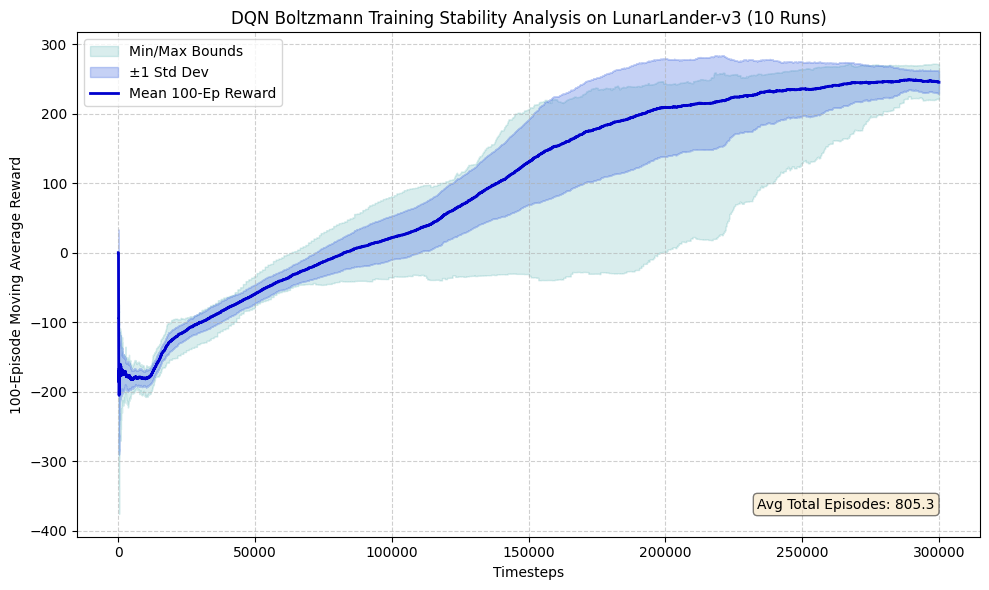

In [17]:
import os

# Configuration
N_RUNS = 10
SAVE_DIR = "./DQN_Boltzmann_stability_analysis"

all_runs_logs = []
all_runs_lengths_logs = []

print(f"Loading Stability Analysis data for {N_RUNS} runs from '{SAVE_DIR}'...")

# --- LOAD DATA FROM SAVED ARRAYS ---
for run in range(N_RUNS):
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    if os.path.exists(reward_file) and os.path.exists(length_file):
        # Load the step-by-step reward history
        run_history = np.load(reward_file).tolist()
        # Load the scalar episode count (.item() extracts the scalar from the 0D array)
        run_lengths_history = np.load(length_file).item()
        
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        print(f"-> Successfully loaded Run {run + 1} (Total Episodes: {run_lengths_history})")
    else:
        raise FileNotFoundError(f"Missing data files for Run {run + 1}. Please ensure both {reward_file} and {length_file} exist.")

print("\nAll data loaded successfully! Processing metrics and generating stability plot...")

# --- PROCESS METRICS ---
# Convert to a 2D numpy array: shape (N_RUNS, timesteps_logged)
data_matrix = np.array(all_runs_logs)

# Calculate stats across the runs (axis=0)
mean_trend = np.mean(data_matrix, axis=0)
std_trend = np.std(data_matrix, axis=0)
min_trend = np.min(data_matrix, axis=0)
max_trend = np.max(data_matrix, axis=0)

# Since your training loop saved data at EVERY timestep, your effective LOG_FREQ is 1
effective_log_freq = 1
x_axis = np.arange(len(mean_trend)) * effective_log_freq

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# 1. Fill the Min/Max total range (Light Cyan shadow)
plt.fill_between(
    x_axis, 
    min_trend, 
    max_trend, 
    color="darkcyan", 
    alpha=0.15, 
    label="Min/Max Bounds"
)

# 2. Fill the Standard Deviation shadow (Royal Blue shadow)
plt.fill_between(
    x_axis, 
    mean_trend - std_trend, 
    mean_trend + std_trend, 
    color="royalblue", 
    alpha=0.3, 
    label="±1 Std Dev"
)

# 3. Plot the mean line (Deep Blue line)
plt.plot(x_axis, mean_trend, label="Mean 100-Ep Reward", color="mediumblue", lw=2)

# Graph embellishments
plt.title(f"DQN Boltzmann Training Stability Analysis on LunarLander-v3 ({N_RUNS} Runs)")
plt.xlabel("Timesteps")
plt.ylabel("100-Episode Moving Average Reward")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

# Display total average episodes completed across all runs as text on the plot
avg_final_episodes = np.mean(all_runs_lengths_logs)
plt.text(0.95, 0.05, f"Avg Total Episodes: {avg_final_episodes:.1f}", 
         transform=plt.gca().transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()